# FORESEE Models: Protophobic

## Load Libraries 

In [1]:
import numpy as np
import sys
import os
src_path = "/Users/felixkling/Documents/GitHub/FORESEE/"
sys.path.append(src_path)
from src.foresee import Foresee, Utility, Model
from matplotlib import pyplot as plt

In [2]:
efficiency_functions = {
    1500: {
        'gamma gamma': '0.761/(1+np.exp(-(energy-1500)/14.957))',
        'pi0 gamma': '0.786/(1+np.exp(-(energy-1500)/15.338))',
        'pi0 pi0': '0.727/(1+np.exp(-(energy-1500)/15.534))',
        'pi0 pi0 pi0': '0.656/(1+np.exp(-(energy-1500)/15.289))',
        'e+ e-': '0.488/(1+np.exp(-(energy-1500)/14.92))',
        'pi+ pi- gamma': '0.117(1./(1+np.exp(-(energy-2618)/262))+ 1./(1+np.exp(-(energy-4043)/558)))',
        'pi+ pi- pi0': '0.15(1./(1+np.exp(-(energy-2537)/278))+ 1./(1+np.exp(-(energy-4115)/628)))',
    },
}

## 1. Specifying the Model

The phenomenology of the protophobic gauge boson $A'$ can be described by the following Lagrangian

\begin{equation}
 \mathcal{L} = \frac{1}{2} \color{red}{m_{A'}}^2 A'^2  - \color{red}{g} \sum  x_f \ \bar f \gamma^\mu f A'_\mu
\end{equation}

with the dark photon mass $m_{A'}$ and the coupling $g$ as free parameters. The parameters $x_f$ specify the couplings to different fermions, in this case $x_u = -1/3$, $x_d=2/3$, $x_e=-1$ and $x_\nu=0$ for all three generations. For the search for the gauge boson at forward experiments we need to know i) the *production rate*, ii) the *lifetime* and iii) possibly the *decay branching fractions* of dark photons as function of those two parameters. All properties are specified in the `Model` class. We initialize it with the name of the model as argument. 


In [3]:
energy = "13.6"
modelname="Protophobic"
model = Model(modelname, path="./")

**Production** Most LLPs are produced in the decay of primary particles. Here we need to specify the total branching fraction into the LLP as function of the `coupling` and the `mass`. We additionally specify the variable `nsample` which specifies how often each parent particle is decayed. 

At first, let's look at the pseudo scalar decays $\pi^0, \eta, \eta' \to A' \gamma$. The corresponding branching fractions can be found in Tab. 3 of [1801.04847](https://arxiv.org/pdf/1801.04847.pdf). Notably, for the protophobic gauge boson, the decay width of $\pi^0 \to A' \gamma$ is strongly suppressed. The dominant contribution therefore comes from the $\eta$ and $\eta'$ decays.  

\begin{equation}
\begin{aligned}
    \text{BR}(\pi^0 \to A' \gamma) &\approx 0  \\
    \text{BR}(\eta \to A' \gamma)  &= 2 (g/e)^2 \times\text{BR}(\eta \to \gamma\gamma) \times 
    \left(1-m_{A'}^2/m_\eta^2\right)^3 \times [\frac{1}{8}BW_\omega(m) - \frac{9}{8} BW_\rho(m) + \frac{4}{8} BW_\phi(m)]^2 \approx  0.5 (g/e)^2 \times\text{BR}(\eta \to \gamma\gamma) \times 
    \left(1-m_{A'}^2/m_\eta^2\right)^3 \\
    \text{BR}(\eta' \to A' \gamma)  &= 2 (g/e)^2 \times\text{BR}(\eta' \to \gamma\gamma) \times \left(1-m_{A'}^2/m_{\eta'}^2\right)^3 \times [\frac{1}{14}BW_\omega(m) - \frac{9}{14} BW_\rho(m) - \frac{8}{14} BW_\phi(m)]^2  \approx 128/49 (g/e)^2 \times\text{BR}(\eta' \to \gamma\gamma) \times \left(1-m_{A'}^2/m_{\eta'}^2\right)^3 
\end{aligned}
\end{equation}

where $BW_{V} = (1-m_{A'}^2/m_V^2 - i \Gamma_V/m_V)^{-1}$.

In [4]:
model.add_production_2bodydecay(
    pid0 = "221",
    pid1 = "22",
    br = "2.*0.39 * (coupling/0.3)**2 * pow(1.-pow(mass/self.masses('221'),2),3) * np.abs(1./8.*(1-mass**2/0.78265**2 - 0.00849/0.78265*1j)**(-1) - 9./8.*(1-mass**2/0.77545**2 - 0.147/0.77545*1j)**(-1) + 4./8.*(1-mass**2/1.019461**2)**(-1))**2",
    generator = ['EPOSLHC', 'SIBYLL', 'QGSJET', 'Pythia8-Forward'],
    energy = energy,
    nsample = 1000, 
)

Dark photons can also be produced via dark Bremsstrahlung, so coherent radiation off a proton in processes such as $p p \to p p A'$. The spectra for LLPs have been exbtained following the description in [1708.09389](https://arxiv.org/abs/1708.09389) and are provided in the `files/direct` directory. As the FWW apprixmation loose validaty at high pT, we impose a cut on the pT of the dark photon and study the associated uncertainy by varing that cut as `0.5`, `1`, `2` GeV.


In [5]:
masses_brem = [ 
    0.001, 0.002, 0.003, 0.005, 0.007, 0.01 , 0.015, 0.02 , 0.03 , 
    0.04 , 0.06 , 0.08 , 0.1  , 0.14 , 0.175, 0.21 , 0.245, 0.28 ,
    0.315, 0.35 , 0.385, 0.42 , 0.455, 0.49 , 0.525, 0.56 , 0.595,
    0.63 , 0.665, 0.7  , 0.71 , 0.72 , 0.73 , 0.74 , 0.75 , 0.76 ,
    0.77 , 0.78 , 0.79 , 0.8  , 0.81 , 0.82 , 0.83 , 0.84 , 0.85 ,
    0.86 , 0.87 , 0.88 , 0.89 , 0.9  , 0.91 , 0.92 , 0.93 , 0.94 ,
    0.95 , 0.96 , 0.97 , 0.98 , 0.99 , 1.   , 1.01 , 1.02 , 1.03 ,
    1.04 , 1.05 , 1.06 , 1.07 , 1.08 , 1.09 , 1.1  , 1.12 , 1.14 ,
    1.16 , 1.18 , 1.2  , 1.22 , 1.24 , 1.26 , 1.28 , 1.3  , 1.32 ,
    1.34 , 1.36 , 1.38 , 1.4  , 1.42 , 1.44 , 1.46 , 1.48 , 1.5  ,
    1.525, 1.55 , 1.575, 1.6  , 1.625, 1.65 , 1.675, 1.7  , 1.725,
    1.75 , 1.775, 1.8  , 1.825, 1.85 , 1.875, 1.9  , 1.95 , 2.0  , 
]

In [6]:
model.add_production_direct(
    label = "Brem_QRA",
    energy = energy,
    condition = None,
    configuration = [
        "Brem_Model1_L0","Brem_Model1_Lu","Brem_Model1_Ld",
        "Brem_Model2_L0","Brem_Model2_Lu","Brem_Model2_Ld",
        "Brem_Model3_L0","Brem_Model3_Lu","Brem_Model3_Ld",
    ],
    coupling_ref=0.303,
    masses = masses_brem,
)

#model.add_production_direct(
#    label = "Brem_FWW",
#    energy = energy,
#    condition = ["p.pt<1", "p.pt<2", "p.pt<0.5", "1"],
#    configuration = ["Brem_FWW"],
#    coupling_ref=1,
#    masses = masses_brem,
#)

#model.add_production_direct(
#    label = "Brem_QRA",
#    energy = energy,
#    condition = None,
#    configuration = ["Brem_QRAD_1","Brem_QRAD_1.5","Brem_QRAD_2"],
#    coupling_ref=1,
#    masses = masses_brem,
#)

In [7]:
masses_brem_tan = [
    0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.55, 
    0.60, 0.65, 0.70, 0.73, 0.75, 0.77, 0.79, 0.82, 0.85, 0.90, 
    0.95, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50, 1.60, 1.70, 1.80, 
    1.90, 2.00 
]

In [8]:
model.add_production_direct(
    label = "Brem_TAN",
    energy = energy,
    condition = None,
    configuration = [
        "BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld",
        "BremTAN_SIBYLL_Model1_L0" , "BremTAN_QGSJET_Model1_L0" , 
        "BremTAN_EPOSLHC_Model2_L0", "BremTAN_EPOSLHC_Model3_L0", 
    ],
    coupling_ref=0.303,
    masses = masses_brem_tan,
)

At high masses, the production of dark photons is dominated by Drell-Yan production, so quark-anti-quark fusion $q q \to A' + X$. Here we use the dark photon spectra obtained in [1810.01879](https://arxiv.org/pdf/1810.01879.pdf) using MadGraph plus Pythia, which are provided in the `files/direct` directory. 

In [9]:
#masses_dy = [1.5849, 1.7783, 1.9953,2.2387, 2.5119, 2.8184, 3.1623, 3.9811, 5.0119, 6.3096, 7.9433, 10.]
#model.add_production_direct(
#    label = "DY",
#    energy = energy,
#    coupling_ref=1,
#    masses = masses_dy,
#    condition='True',
#)

**Decay:** Dark photons can decay into all kinematically accessible light charged states, with a decay width proportional to $\epsilon^2$. Here we use the lifetime and the decay branching fractions as presented in [1801.04847](https://arxiv.org/abs/1801.04847) for the DarkCast tool. 

In [10]:
model.set_ctau_1d(
    filename="model/ctau.txt", 
)

decay_modes = ["bfrac_elec"] 
model.set_br_1d(
    modes = decay_modes,
    finalstates=[[11,-11]],
    filenames=["model/br/"+mode+".txt" for mode in decay_modes],
)

We can now initiate FORESEE with the model that we just created. 

In [11]:
foresee = Foresee(path=src_path)
foresee.set_model(model=model)

## 2. Event Generation

In the following, we want to study one specific benchmark point with $m_{A'}=50$ MeV and $\epsilon=3\cdot 10^{-5}$ and export events as a HEPMC file. 

In [12]:
mass, coupling, = 0.017, 2e-5

First, we will produce the corresponding flux for this mass and a reference coupling $\epsilon_{ref}=1$. 

save data to file: ./model/LLP_spectra/13.6TeV_221_EPOSLHC_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_SIBYLL_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_QGSJET_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_Pythia8-Forward_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model1_L0_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model1_Lu_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model1_Ld_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model2_L0_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model2_Lu_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model2_Ld_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model3_L0_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model3_Lu_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV

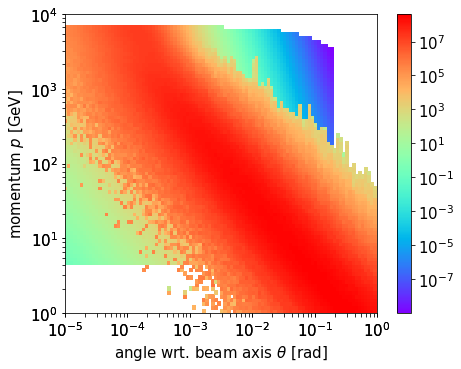

In [13]:
plot=foresee.get_llp_spectrum(mass=mass, coupling=1, do_plot=True)
plot.show()

Next, let us define the configuration of the detector (in terms of position, size and luminosity). Here we choose FASER during 2022/2023. 

In [14]:
foresee.set_detector(
    distance=474,
    selection="np.sqrt(x.x**2 + (x.y+0.065)**2)< .1", 
    length=4.0, 
    luminosity=57.7, 
    efficiency="0.81 / (1+np.exp(-(energy-1500)/15))", 
)

For our benchmark point, let us now look at how many particle decay inside the decay volume. We also export 1000 unweighted events as a HEPMC file. 

In [16]:
setupnames = ['EPOSLHC', 'SIBYLL', 'QGSJET']
modes = {
    '221':['EPOSLHC', 'SIBYLL', 'QGSJET'], 
    "Brem_QRA": ["Brem_Model1_L0","Brem_Model1_Ld","Brem_Model1_Lu"],
    "Brem_TAN": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld"],
}

momenta, weights, _ = foresee.write_events(
    mass = mass, 
    coupling = coupling, 
    energy = energy, 
    numberevent = 1000,
    filename = "model/events/test.hepmc", 
    return_data = True,
    weightnames=setupnames,
    modes=modes,
    nsample=30,
)

for isetup, setup in enumerate(setupnames):
    print("Expected number of events for "+setup+":", round(sum(weights[:,isetup]),3))

Expected number of events for EPOSLHC: 62.359
Expected number of events for SIBYLL: 78.775
Expected number of events for QGSJET: 28.608


Let us plot the resulting energy distribution

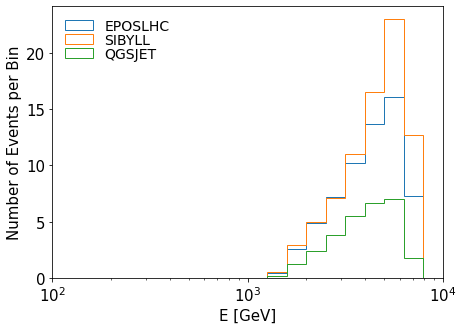

In [17]:
fig = plt.figure(figsize=(7,5))
ax = plt.subplot(1,1,1)
energies = [p.e for p in momenta], 
for isetup, setup in enumerate(setupnames):
    ax.hist(energies, weights=weights[:,isetup], bins=np.logspace(2,4, 20+1), histtype='step', label=setup) 
ax.set_xscale("log")
ax.set_xlim(1e2,1e4) 
ax.set_xlabel("E [GeV]") 
ax.set_ylabel("Number of Events per Bin") 
ax.legend(frameon=False, labelspacing=0, fontsize=14, loc='upper left')
plt.show()

## 2A Benchmark Study

In [28]:
mass, coupling, = 0.017, 2e-5

save data to file: ./model/LLP_spectra/13.6TeV_221_EPOSLHC_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_SIBYLL_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_QGSJET_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_221_Pythia8-Forward_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model1_L0_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model1_Lu_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model1_Ld_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model2_L0_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model2_Lu_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model2_Ld_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model3_L0_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV_Brem_QRA_Brem_Model3_Lu_m_0.017.npy
save data to file: ./model/LLP_spectra/13.6TeV

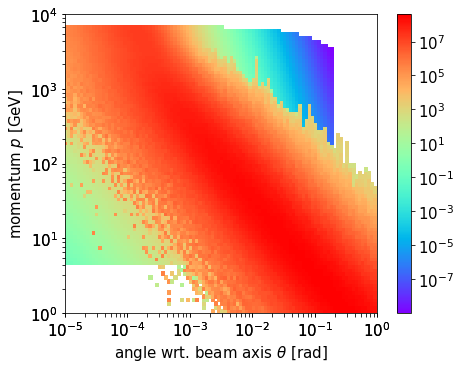

In [24]:
plot=foresee.get_llp_spectrum(mass=mass, coupling=1, do_plot=True)
plot.show()

In [29]:
#setup detector
foresee.set_detector(
    distance=474,
    selection="np.sqrt(x.x**2 + (x.y+0.065)**2)< .1", 
    length=4.0, 
    luminosity=57.7, 
    efficiency=efficiency_functions[1500]['e+ e-'], 
    channels=['bfrac_elec'],
)
setupnames = ['A', 'B', 'C']


# mesons
modes = {'221': ['EPOSLHC', 'SIBYLL', 'QGSJET']}
_,_,_,momenta_meson, weights_meson  = foresee.get_events(mass = mass, couplings = [coupling], 
    energy = energy,  nsample=30, modes=modes,)

#brem QRA
modes = {"Brem_QRA": ["Brem_Model1_L0","Brem_Model1_Lu","Brem_Model1_Ld"]}
_,_,_,momenta_Brem, weights_Brem  = foresee.get_events(mass = mass, couplings = [coupling], 
    energy = energy,  nsample=30, modes=modes,)


#Brem TAN
foresee.set_detector(
    distance=474,
    selection="np.sqrt(x.x**2 + (x.y+0.065)**2)< .1", 
    length=4.0, 
    luminosity=57.7, 
    efficiency=efficiency_functions[1500]['e+ e-'], 
    channels=['bfrac_elec'],
    distance_prod=140,
)


modes = {"Brem_TAN": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld"]}
_,_,_,momenta_TAN, weights_TAN  = foresee.get_events(mass = mass, couplings = [coupling], 
    energy = energy,  nsample=30, modes=modes,)

modes = {"Brem_TAN": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_SIBYLL_Model1_L0" , "BremTAN_QGSJET_Model1_L0" ]}
_,_,_,momenta_TAN_MG, weights_TAN_MG  = foresee.get_events(mass = mass, couplings = [coupling], 
    energy = energy,  nsample=30, modes=modes,)

modes = {"Brem_TAN": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model2_L0", "BremTAN_EPOSLHC_Model3_L0"]}
_,_,_,momenta_TAN_M, weights_TAN_M  = foresee.get_events(mass = mass, couplings = [coupling], 
    energy = energy,  nsample=30, modes=modes,)

#Summary
for isetup, setup in enumerate(setupnames):
    if isetup>0: continue
    print("Expected number of events for "+setup+"")
    print(" -  221:", round(sum(weights_meson[0][:,isetup]),3)) 
    print(" - Brem:", round(sum(weights_Brem[0][:,isetup]),3)) 
    print(" -  TAN:", round(sum(weights_TAN[0][:,isetup]),3)) 

Expected number of events for A
 -  221: 6.117
 - Brem: 27.958
 -  TAN: 7.173


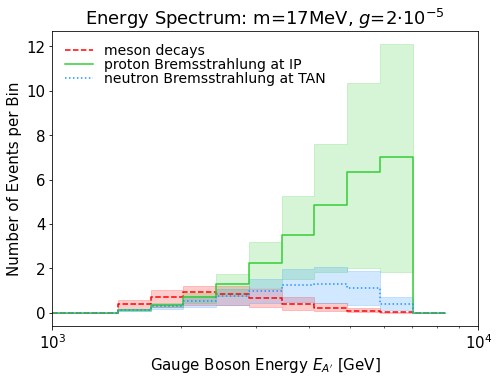

In [30]:
fig = plt.figure(figsize=(7,5))
ax = plt.subplot(1,1,1)
bins=np.logspace(3,4, 13+1)
centers=(bins[1:]+bins[:-1])/2

labels   = ["meson decays", "proton Bremsstrahlung at IP","neutron Bremsstrahlung at TAN"]
colors   = ["red", "limegreen", "dodgerblue"]
momentas = [momenta_meson, momenta_Brem,momenta_TAN]
weightss = [weights_meson, weights_Brem,weights_TAN]
linels   = ["dashed", "solid", "dotted"]
for label,color,momenta, weights,ls in zip(labels,colors,momentas,weightss,linels):
    if label == "": continue
    energies = [p.e for p in momenta] 
    yvals=[]
    for isetup, setup in enumerate(setupnames):
        y, _ = np.histogram(energies, weights=weights[0][:,isetup],  bins=bins)
        y[-2]=0
        yvals.append(y)
    yvals = np.array(yvals)
    yvals_avg = [np.mean(row) for row in yvals.T]
    yvals_min = [min(row) for row in yvals.T]
    yvals_max = [max(row) for row in yvals.T]
    ax.plot(bins[:-1], yvals_avg, color=color, label=label, drawstyle='steps-post',ls=ls)
    ax.fill_between(bins[:-1], yvals_min, yvals_max, color=color, alpha=0.2,step='post')
            

ax.set_xscale("log")
ax.set_xlim(1e3,1e4)  
ax.set_xlabel(r"Gauge Boson Energy $E_{A'}$ [GeV]") 
ax.set_ylabel("Number of Events per Bin") 
ax.legend(frameon=False, labelspacing=0, fontsize=14, loc='upper left')
#ax.set_title(r"m="+str(mass)+"GeV, $\epsilon$="+str(coupling))
ax.set_title(r"Energy Spectrum: m="+str(int(mass*1000))+"MeV, $g$="+str(int(coupling/1e-5))+"$\cdot 10^{-5}$")

plot.subplots_adjust(left=0.13, right=0.975, bottom=0.115, top=0.935)
plot.savefig("Energy_"+modelname+".pdf")
plt.show()

## 3. Sensitivity Reach

In the following, we will obtain the projected sensitivity for the LLP model. For this, we first define a grid of couplings and masses, and then produce the corresponding fluxes. 

In [12]:
masses=[round(x,5) for x in np.logspace(-2,0.3,92+1)]
couplings = np.logspace(-8,-3,101) 

#for mass in masses: foresee.get_llp_spectrum(mass=mass,coupling=1,channels=["Brem_QRA"])

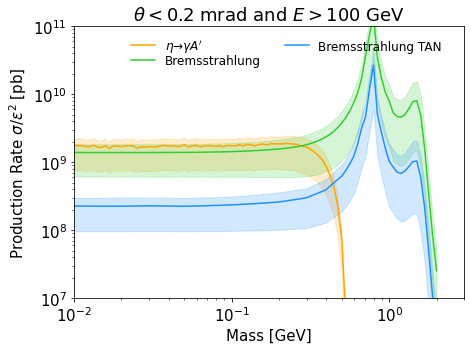

In [23]:
productions=[
    {"channels": ["221"]     , "color": "orange"    , "label": r"$\eta \to \gamma A'$" , "generators": ["EPOSLHC","QGSJET","SIBYLL"]  },
    {"channels": ["Brem_QRA"], "color": "limegreen" , "label": r"Bremsstrahlung"       , "generators": ["Brem_Model1_L0", "Brem_Model1_Lu", "Brem_Model1_Ld"]},
    {"channels": ["Brem_TAN"], "color": "dodgerblue", "label": r"Bremsstrahlung TAN"   , "generators": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld"]},
]

plot=foresee.plot_production(
    masses = masses,
    productions = productions,
    energy=energy,
    condition="logth<-3.7 and logp>2",  
    xlims=[0.01,3],ylims=[1e7,1e11],
    xlabel=r"Mass [GeV]",
    ylabel=r"Production Rate $\sigma/g^2$ [pb]",
    title=r"$\theta < 0.2$ mrad and $E > 100$ GeV",
    legendloc=(0.97,1),
    fs_label=12,
    ncol=2,
)

plot.savefig("photon_production_channels_E100.pdf")
plot.show()

No handles with labels found to put in legend.


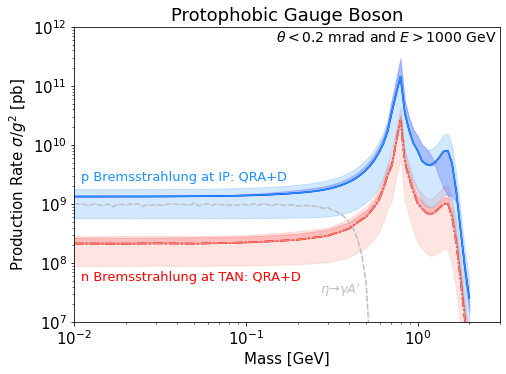

In [14]:
productions=[
    {"channels": ["221"]     , "color": "silver"    ,"ls": 'dashed' , "label": r"", "generators": ["EPOSLHC"]  },
    {"channels": ["Brem_TAN"], "color": "firebrick" ,"ls": 'dashdot', "label": r"", "generators": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model2_L0", "BremTAN_EPOSLHC_Model3_L0"]},
    {"channels": ["Brem_TAN"], "color": "red"       ,"ls": 'dashdot', "label": r"", "generators": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_SIBYLL_Model1_L0", "BremTAN_QGSJET_Model1_L0"]},
    {"channels": ["Brem_TAN"], "color": "salmon"    ,"ls": 'dashdot', "label": r"", "generators": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld"]},
    {"channels": ["Brem_QRA"], "color": "blue"      ,"ls": 'solid'  , "label": r"", "generators": ["Brem_Model1_L0", "Brem_Model2_L0", "Brem_Model3_L0"]},
    {"channels": ["Brem_QRA"], "color": "dodgerblue","ls": 'solid'  , "label": r"", "generators": ["Brem_Model1_L0", "Brem_Model1_Lu", "Brem_Model1_Ld"]},
]

plot=foresee.plot_production(
    masses = masses,
    productions = productions,
    energy=energy,
    condition="logth<-3.7 and logp>3",  
    xlims=[0.01,3],ylims=[1e7,1e12],
    xlabel=r"Mass [GeV]",
    ylabel=r"Production Rate $\sigma/g^2$ [pb]",
    title="Protophobic Gauge Boson",
    legendloc=(0.97,1),
    fs_label=12,
    ncol=2,
)

plot.text(2.9, 9e11,r"$\theta < 0.2$ mrad and $E > 1000$ GeV", fontsize=14, ha='right', va='top')
plot.text(2.7e-1, 0.3e8, r"$\eta \to \gamma A'$"           , fontsize=13, color='silver')
plot.text(1.1e-2, 2.5e9, "p Bremsstrahlung at IP: QRA+D" , fontsize=13, color='dodgerblue')
plot.text(1.1e-2, 5.0e7, "n Bremsstrahlung at TAN: QRA+D" , fontsize=13, color='red')

plot.subplots_adjust(left=0.13, right=0.975, bottom=0.115, top=0.935)
plot.savefig("Prod_Protophobic.pdf")
plot.show()

Let us now scan over various masses and couplings, and record the resulting number of evets. Note that here we again consider the FASER configuration, which we set up before.

In [23]:
setupnames = ['EPOSLHC', 'SIBYLL', 'QGSJET']
modes = {'221': ['EPOSLHC', 'SIBYLL', 'QGSJET']}

# initialize
list_nevents = {label:[] for label in setupnames}

# define relevant final states: 
final_states = {'bfrac_elec': 'e+ e-'}

# loop over final states
for ichannel, (channel, final_state) in enumerate(final_states.items()):
    #define detector
    foresee.set_detector(
        distance=474,
        selection="np.sqrt(x.x**2 + (x.y+0.065)**2)< .1", 
        length=4.0, 
        luminosity=57.7, 
        efficiency=efficiency_functions[1500][final_state], 
        channels=[channel],
    )
    for imass, mass in enumerate(masses):
        couplings, _, nevents, _, _  = foresee.get_events(mass=mass, energy=energy, couplings = couplings, modes=modes, nsample=10)
        if ichannel==0: 
            for i,label in enumerate(setupnames): list_nevents[label].append(nevents.T[i])  
        else:           
            for i,label in enumerate(setupnames): list_nevents[label][imass]+=nevents.T[i]

#save results
configuration='meson'
for label in setupnames: 
    result = np.array([masses,couplings,list_nevents[label]], dtype='object')
    np.save("model/results/"+energy+"TeV_"+configuration+"_"+label+".npy",result)

In [24]:
setupnames = ['EPOSLHC', 'SIBYLL', 'QGSJET']
modes = {'221':['EPOSLHC', 'SIBYLL', 'QGSJET'],  "Brem_QRA": ["Brem_Model1_L0", "Brem_Model1_Lu", "Brem_Model1_Ld"],}

# initialize
list_nevents = {label:[] for label in setupnames}

# define relevant final states: 
final_states = {'bfrac_elec': 'e+ e-'}

# loop over final states
for ichannel, (channel, final_state) in enumerate(final_states.items()):
    #define detector
    foresee.set_detector(
        distance=474,
        selection="np.sqrt(x.x**2 + (x.y+0.065)**2)< .1", 
        length=4.0, 
        luminosity=57.7, 
        efficiency=efficiency_functions[1500][final_state], 
        channels=[channel],
    )
    for imass, mass in enumerate(masses):
        couplings, _, nevents, _, _  = foresee.get_events(mass=mass, energy=energy, couplings = couplings, modes=modes, nsample=10)
        if ichannel==0: 
            for i,label in enumerate(setupnames): list_nevents[label].append(nevents.T[i])  
        else:           
            for i,label in enumerate(setupnames): list_nevents[label][imass]+=nevents.T[i]

#save results
configuration='qra'
for label in setupnames: 
    result = np.array([masses,couplings,list_nevents[label]], dtype='object')
    np.save("model/results/"+energy+"TeV_"+configuration+"_"+label+".npy",result)

In [27]:
setupnames = ['EPOSLHC', 'SIBYLL', 'QGSJET']

# initialize
list_nevents = {label:[] for label in setupnames}

# define relevant final states: 
final_states = {'bfrac_elec': 'e+ e-'}

# loop over final states: mesons and Brem
modes = {'221':['EPOSLHC', 'SIBYLL', 'QGSJET'],  "Brem_QRA": ["Brem_Model1_L0", "Brem_Model1_Lu", "Brem_Model1_Ld"],}
for ichannel, (channel, final_state) in enumerate(final_states.items()):
    #define detector
    foresee.set_detector(
        distance=474,
        selection="np.sqrt(x.x**2 + (x.y+0.065)**2)< .1", 
        length=4.0, 
        luminosity=57.7, 
        efficiency=efficiency_functions[1500][final_state], 
        channels=[channel],
    )
    for imass, mass in enumerate(masses):
        couplings, _, nevents, _, _  = foresee.get_events(mass=mass, energy=energy, couplings = couplings, modes=modes, nsample=10)
        if ichannel==0: 
            for i,label in enumerate(setupnames): list_nevents[label].append(nevents.T[i])  
        else:           
            for i,label in enumerate(setupnames): list_nevents[label][imass]+=nevents.T[i]

# loop over final states: TAN only
modes = {"Brem_TAN": ["BremTAN_EPOSLHC_Model1_L0", "BremTAN_EPOSLHC_Model1_Lu", "BremTAN_EPOSLHC_Model1_Ld"],}
for ichannel, (channel, final_state) in enumerate(final_states.items()):
    #define detector
    foresee.set_detector(
        distance=474,
        selection="np.sqrt(x.x**2 + (x.y+0.065)**2) < .1", 
        length=4.0, 
        luminosity=57.7, 
        efficiency=efficiency_functions[1500][final_state], 
        channels=[channel],
        distance_prod=140,
    )
    for imass, mass in enumerate(masses):
        couplings, _, nevents, _, _  = foresee.get_events(mass=mass, energy=energy, couplings = couplings, modes=modes, nsample=10)
        for i,label in enumerate(setupnames): list_nevents[label][imass]+=nevents.T[i]
        
#save results
configuration='all'
for label in setupnames: 
    result = np.array([masses,couplings,list_nevents[label]], dtype='object')
    np.save("model/results/"+energy+"TeV_"+configuration+"_"+label+".npy",result)

We can now plot the results. For this, we first specify all detector setups for which we want to show result (filename in model/results directory, label, color, linestyle, opacity alpha for filled contours, required number of events).

## Plot

Then we specify all the existing bounds, separating the bounds obtained by experimental collaboratios and theory recasts. 

In [18]:
bounds2 = [ 
    ["bounds_Anomaly.txt",    "Anomaly",  0.025, 1e-4, 0  ],
]
bounds = [ 
    ["bounds_Orsay_Davier1989wz.txt"          , "Orsay", 0.042 , 2.5*10**-6 , -28],
    ["bounds_E141_Riordan1987aw.txt"          , "E141",  0.011 , 1.8*10**-5 , 0  ],
    ["bounds_NA64_Banerjee2019hmi.txt"        , "NA64",  0.014 , 1.0*10**-4 , -35],
    ["bounds_KLOE_Anastasi2015qla.txt"        , "KLOE",  0.011 , 7.0*10**-4 , 0  ],
    ["bounds_BaBar_Lees2014xha.txt"           , "BaBar", 0.060 , 7.0*10**-4 , 0  ],
    ["bounds_PADME.txt"                       , "PADME", 0.018 , 3*10**-4 , 0],
]

In [19]:
setups = [ 
    ["13.6TeV_meson_EPOSLHC.npy", "only $\eta$-decay"    , "red"        ,  "dashed"  , 0, 3.6],
#    ["13.6TeV_qra_EPOSLHC.npy",   "incl. proton Bremsstrahlung" , "limegreen" ,  "dashdot"  , 0, 3.6],
#    ["13.6TeV_meson_EPOSLHC.npy", "FASER Paper" , "red"        ,  "solid"  , 0, 3.6],
    ["13.6TeV_all_EPOSLHC.npy",   "incl. Bremsstrahlung" , "dodgerblue" ,  "solid"  , 0, 3.6],
]

In [20]:
def plot_band(setup0, setup1, nevents=3):
    foresee.extract_contours("model/results/"+setup0,"model/lines/limits_0.txt",nevents=nevents)
    foresee.extract_contours("model/results/"+setup1,"model/lines/limits_1.txt",nevents=nevents)
    data0 = foresee.readfile("model/lines/limits_0.txt")
    data1 = foresee.readfile("model/lines/limits_1.txt")
    data=[]
    for x, y in data0: data.append([x,y])
    for x, y in np.flip(data1,0): data.append([x,y])
    return np.array(data)

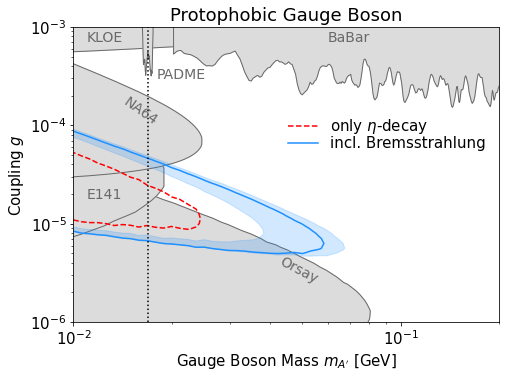

In [22]:
data1=plot_band("13.6TeV_meson_EPOSLHC.npy", "13.6TeV_meson_QGSJET.npy",nevents=3.6)
data2=plot_band("13.6TeV_qra_SIBYLL.npy", "13.6TeV_qra_QGSJET.npy",nevents=3.6)
data3=plot_band("13.6TeV_all_SIBYLL.npy", "13.6TeV_all_QGSJET.npy",nevents=3.6)

plot = foresee.plot_reach(
    setups=setups,
    bounds=bounds,
#    bounds2=bounds2,
    projections=[],
    branchings=None,
    title="Protophobic Gauge Boson", 
    xlims = [0.01,0.20], 
    ylims=[1e-6,0.001],
    xlabel=r"Gauge Boson Mass $m_{A'}$ [GeV]", 
    ylabel=r"Coupling $g$",
    legendloc=(1.0,0.74),
    figsize=(7,5),
)

#plot.fill(data1.T[0], data1.T[1], color='red', alpha=0.2)
#plot.fill(data2.T[0], data2.T[1], color='limegreen', alpha=0.2)
plot.fill(data3.T[0], data3.T[1], color='dodgerblue', alpha=0.2)
plot.plot([0.0169,0.0169],[1e-6,0.002],ls='dotted', c='k')

plot.subplots_adjust(left=0.13, right=0.975, bottom=0.115, top=0.935)
plot.savefig("Reach_"+modelname+".pdf")
plot.show()